In [ ]:
import copy
import math
import torch
import numpy as np
import torch.nn as nn
from torch import Tensor
from functools import partial
import torchvision.transforms.functional as F_trans
import torch.nn.functional as F
from typing import Any, Callable, Dict, List, Optional, Sequence, Tuple, Union
from torchvision.models.resnet import BasicBlock, Bottleneck, conv1x1
from torchvision.transforms import InterpolationMode
import ee
import pandas as pd
import openpyxl
import datetime
import os
from PIL import Image
import numpy as np
import json
import IPython.display as disp
import os
import json
import torch
import numpy as np
from PIL import Image
from skimage.io import imread
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import ConcatDataset, DataLoader, SubsetRandomSampler
from torchvision import transforms
from skimage.io import imread
import matplotlib.pyplot as plt
import os
import time
import csv

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install --upgrade pillow

In [ ]:
!cp "/content/drive/Othercomputers/MiPC/Code_OilSpill/training_mod/encoder_models.py" "/content/"
!cp "/content/drive/Othercomputers/MiPC/Code_OilSpill/training_mod/decoder_models.py" "/content/"
!cp "/content/drive/Othercomputers/MiPC/Code_OilSpill/training_mod/seg_models.py" "/content/"
!cp "/content/drive/Othercomputers/MiPC/Code_OilSpill/training/metrics.py" "/content/"
!cp "/content/drive/Othercomputers/MiPC/Code_OilSpill/training/logger_utils.py" "/content/"
!cp "/content/drive/Othercomputers/MiPC/Code_OilSpill/training_mod/train.py" "/content/"

In [ ]:
# Set the paths to your dataset
#dir_data = '/content/drive/MyDrive/CIMA2023/Documentos2023/Proyectos/Proy1-ImagenesEspectrales/data/imagenes/OilDataset/train/'
#list_images = os.listdir(os.path.join(dir_data, "images"))
#sos_dir = '/content/drive/Othercomputers/MiPC/filtered_patches/train'
krest_dir = '/content/drive/Othercomputers/MiPC/subset_TRAIN'

from logger_utils import CSVWriter, write_dict_to_json
from seg_models import ResNet34DeepLabV3Plus,ResNet50DeepLabV3Plus,ResNet101DeepLabV3Plus
from seg_models import EfficientNetMDeepLabV3, ResNet34UNet, ResNet34UNetWithASPP
from metrics import compute_mean_pixel_acc, compute_mean_IOU, compute_class_IOU
#from train import PolynomialLR, validation_loop, train_loop

In [ ]:
#krest_dir = '/content/drive/Othercomputers/MiPC/subset_TRAIN'

In [ ]:
from torchvision.models.resnet import (
    ResNet18_Weights,
    ResNet34_Weights,
    ResNet50_Weights,
    ResNet101_Weights,
)
import torch

In [ ]:
class M4DSAROilSpillDataset(Dataset):
    def __init__(
        self,
        images_dir,
        labels_dir,
        transform=None,
        augmentation=None,
    ):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.transform = transform
        self.augmentation = augmentation

        # Get list of image files
        # Get list of image files
        self.image_files = sorted([
            f for f in os.listdir(self.images_dir)
            if (
                # Include SOS images ending with '_sat.jpg'
                f.endswith('_sat.jpg') or
                # Include Krestininis images starting with 'img_' and ending with '.png', but exclude mask files
                (f.startswith('img_') and f.endswith('.png') and not f.endswith('_mask.png') and not f.endswith('_label_1D.png'))
            )
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # Get image file path
        image_file = self.image_files[idx]
        image_path = os.path.join(self.images_dir, image_file)

        # Load image
        image = Image.open(image_path).convert('RGB')

        # Construct corresponding label file name
        if '_sat.jpg' in image_file:
            # SOS Dataset
            label_file = image_file.replace('_sat.jpg', '_label_1D.png')
        elif image_file.startswith('img_'):
            # Krestininis Dataset
            label_file = image_file.replace('.png', '_label_1D.png')
        else:
            raise ValueError(f'Unknown image file format: {image_file}')

        label_path = os.path.join(self.labels_dir, label_file)
        if not os.path.exists(label_path):
            raise FileNotFoundError(f"Label file not found: {label_path}")

        label = Image.open(label_path).convert('L')

        # Apply augmentation if any
        if self.augmentation:
            image, label = self.augmentation(image, label)

        # Apply transformations
        if self.transform:
            image = self.transform(image)
            label = torch.from_numpy(np.array(label, dtype=np.int64))

        return image, label


CAMBIAR NORMALIZACION VALUES

In [ ]:
import torchvision.transforms as transforms
import random

# Image normalization values (adjust based on your dataset statistics)
mean = [0.4853970078639312, 0.4853970078639312, 0.4853970078639312]  # Example values; adjust if necessary
std = [0.17816201511895402, 0.17816201511895402, 0.17816201511895402]

image_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])
def augmentation(image, label):
    # Random horizontal flip
    if random.random() > 0.5:
        image = F_trans.hflip(image)
        label = F_trans.hflip(label)
    # Random vertical flip
    if random.random() > 0.5:
        image = F_trans.vflip(image)
        label = F_trans.vflip(label)
    # Random rotation
    angle = random.choice([0, 90, 180, 270])
    if angle != 0:
        image = F_trans.rotate(image, angle, interpolation=InterpolationMode.BILINEAR)
        label = F_trans.rotate(label, angle, interpolation=InterpolationMode.NEAREST)
    return image, label


In [ ]:
from torch.utils.data import DataLoader, ConcatDataset, SubsetRandomSampler
import numpy as np

def get_dataloaders_for_training(
    sos_dir,
    krest_dir,
    batch_size,
    random_state=None,
    num_workers=4,
):
    datasets = []

    # Handle SOS dataset
    if sos_dir:
        sos_train_images_dir = os.path.join(sos_dir, 'train')
        sos_train_labels_dir = os.path.join(sos_dir, 'train_1D')
        sos_train_dataset = M4DSAROilSpillDataset(
            images_dir=sos_train_images_dir,
            labels_dir=sos_train_labels_dir,
            transform=image_transform,
            augmentation=None,
        )
        datasets.append(sos_train_dataset)

    # Handle Krestininis dataset
    if krest_dir:
        krest_train_images_dir = os.path.join(krest_dir, 'train', 'images')
        krest_train_labels_dir = os.path.join(krest_dir, 'train', 'labels_1D')
        krest_train_dataset = M4DSAROilSpillDataset(
            images_dir=krest_train_images_dir,
            labels_dir=krest_train_labels_dir,
            transform=image_transform,
            augmentation=None,
        )
        datasets.append(krest_train_dataset)

    # Combine datasets
    if not datasets:
        raise ValueError("No datasets provided for training.")
    combined_train_dataset = ConcatDataset(datasets)

    # Create indices for splitting dataset into training and validation
    dataset_size = len(combined_train_dataset)
    indices = list(range(dataset_size))
    split = int(np.floor(0.05 * dataset_size))  # 5% for validation
    if random_state is not None:
        np.random.seed(random_state)
    np.random.shuffle(indices)
    train_indices, valid_indices = indices[split:], indices[:split]

    # Create samplers
    train_sampler = SubsetRandomSampler(train_indices)
    valid_sampler = SubsetRandomSampler(valid_indices)

    # Create data loaders
    train_loader = DataLoader(
        combined_train_dataset,
        batch_size=batch_size,
        sampler=train_sampler,
        num_workers=num_workers,
    )

    valid_loader = DataLoader(
        combined_train_dataset,
        batch_size=batch_size,
        sampler=valid_sampler,
        num_workers=num_workers,
    )

    print("Dataset information:")
    print(f"Number of training samples: {len(train_indices)}")
    print(f"Number of validation samples: {len(valid_indices)}")

    return train_loader, valid_loader


In [ ]:
def get_dataloader_for_inference(
    sos_dir=None,
    krest_dir=None,
    batch_size=1,
    num_workers=4,
):
    datasets = []

    # Handle SOS dataset
    if sos_dir:
        sos_test_images_dir = os.path.join(sos_dir, 'test', 'sat')
        sos_test_labels_dir = os.path.join(sos_dir, 'test_1D')
        sos_test_dataset = M4DSAROilSpillDataset(
            images_dir=sos_test_images_dir,
            labels_dir=sos_test_labels_dir,
            transform=image_transform,
        )
        datasets.append(sos_test_dataset)

    # Handle Krestininis dataset
    if krest_dir:
        krest_test_images_dir = os.path.join(krest_dir, 'test', 'images')
        krest_test_labels_dir = os.path.join(krest_dir, 'test', 'labels_1D')
        krest_test_dataset = M4DSAROilSpillDataset(
            images_dir=krest_test_images_dir,
            labels_dir=krest_test_labels_dir,
            transform=image_transform,
        )
        datasets.append(krest_test_dataset)

    # Combine datasets
    if not datasets:
        raise ValueError("No datasets provided for inference.")
    combined_test_dataset = torch.utils.data.ConcatDataset(datasets)

    # Create data loader
    test_loader = DataLoader(
        combined_test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
    )

    return test_loader, combined_test_dataset


In [ ]:
#all metrics
#validation & train and polinomial loop
from torch.optim.lr_scheduler import _LRScheduler
class PolynomialLR(_LRScheduler):
    """
    PolynomialLR class for the polynomial learning rate scheduler

    ----------
    Attributes
    ----------
    optimizer : object
        object of type optimizer
    max_epochs : int
        maximum number of epochs for which optimization needs to be run
    power : float
        the power term in the polynomial learning rate scheduler (default: 0.9)
    last_epoch : int
        last epoch in the optimization (default: -1)
    min_lr : float
        minimum value for the learning rate (default: 1e-6)
    """

    def __init__(self, optimizer, max_epochs, power=0.9, last_epoch=-1, min_lr=1e-6):
        self.power = power
        self.max_epochs = max_epochs
        self.min_lr = min_lr  # avoid zero lr
        super(PolynomialLR, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        return [
            max(
                base_lr * (1 - self.last_epoch / self.max_epochs) ** self.power,
                self.min_lr,
            )
            for base_lr in self.base_lrs
        ]


def validation_loop(dataset_loader, model, ce_loss, device):
    """
    ---------
    Arguments
    ---------
    dataset_loader : object
        object of type dataloader
    model : object
        object of type model
    ce_loss : object
        object of type cross entropy loss
    device : str
        device on which training needs to be run

    -------
    Returns
    -------
    (valid_loss, valid_acc, valid_IOU) : tuple
        a tuples of torch floats of mean loss, mean accuracy, mean IoU for the validation set
    """
    model.eval()
    size = len(dataset_loader.dataset)
    num_batches = len(dataset_loader)
    valid_loss, valid_acc, valid_IOU = 0, 0, 0

    with torch.no_grad():
        for image, label in dataset_loader:
            image = image.to(device, dtype=torch.float)
            label = label.to(device, dtype=torch.long)

            pred_logits = model(image)
            valid_loss += ce_loss(pred_logits, label)

            pred_probs = F.softmax(pred_logits, dim=1)
            pred_label = torch.argmax(pred_probs, dim=1)

            valid_acc += compute_mean_pixel_acc(label, pred_label)
            valid_IOU += compute_mean_IOU(label, pred_label)

    valid_loss /= num_batches
    valid_acc /= num_batches
    valid_IOU /= num_batches
    return valid_loss, valid_acc, valid_IOU


def train_loop(dataset_loader, model, ce_loss, optimizer, device):
    """
    ---------
    Arguments
    ---------
    dataset_loader : object
        object of type dataloader
    model : object
        object of type model
    ce_loss : object
        object of type cross entropy loss
    optimizer : object
        object of type optimizer
    device : str
        device on which training needs to be run

    -------
    Returns
    -------
    train_loss : torch float
        mean loss for the training set
    """
    model.train()
    size = len(dataset_loader.dataset)
    num_batches = len(dataset_loader)
    train_loss = 0

    for image, label in dataset_loader:
        image = image.to(device, dtype=torch.float)
        label = label.to(device, dtype=torch.long)
        optimizer.zero_grad()

        pred_logits = model(image)
        loss = ce_loss(pred_logits, label)

        # Backpropagation
        loss.backward()
        optimizer.step()

        train_loss += loss
    train_loss /= num_batches
    return train_loss


In [ ]:
class EarlyStopping:
    """Early stops the training if validation loss doesn't improve after a given patience."""
    def __init__(self, patience=7, verbose=False, delta=0, path='checkpoint.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):

        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decreases.'''
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss


In [ ]:
import time
import os
import shutil
def batch_train(FLAGS):
    # Local directory to save models and metrics temporarily
    local_dir = os.path.join('/tmp', 'models', FLAGS.which_model)
    if not os.path.isdir(local_dir):
        os.makedirs(local_dir)
        print(f"Created local directory: {local_dir}")

    # Directory on Google Drive
    dir_path = os.path.join(FLAGS.dir_model, FLAGS.which_model)
    if not os.path.isdir(dir_path):
        os.makedirs(dir_path)
        print(f"Created directory on Google Drive: {dir_path}")

    # Initialize CSVWriter with local file path
    csv_writer = CSVWriter(
        file_name=os.path.join(local_dir, "train_metrics.csv"),  # Save metrics locally first
        column_names=["epoch", "train_loss", "valid_loss", "valid_acc", "valid_IOU"],
    )

    os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Get data loaders
    sos_dir = FLAGS.sos_dir  # Make sure to set this in your FLAGS
    krest_dir = FLAGS.krest_dir  # Make sure to set this in your FLAGS

    train_dataset_loader, valid_dataset_loader = get_dataloaders_for_training(
        sos_dir=sos_dir,
        krest_dir=krest_dir,
        batch_size=FLAGS.batch_size,
        random_state=FLAGS.random_state,
    )

    # Model selection
    if FLAGS.which_model == "resnet_34_deeplab_v3+":
        oil_spill_seg_model = ResNet34DeepLabV3Plus(
            num_classes=FLAGS.num_classes, pretrained=bool(FLAGS.pretrained)
        )
    elif FLAGS.which_model == "resnet_50_deeplab_v3+":
        oil_spill_seg_model = ResNet50DeepLabV3Plus(
            num_classes=FLAGS.num_classes, pretrained=bool(FLAGS.pretrained)
        )
    elif FLAGS.which_model == "resnet_101_deeplab_v3+":
        oil_spill_seg_model = ResNet101DeepLabV3Plus(
            num_classes=FLAGS.num_classes, pretrained=bool(FLAGS.pretrained)
        )
    elif FLAGS.which_model == "efficientnet_v2_m_deeplab_v3":
        oil_spill_seg_model = EfficientNetMDeepLabV3(
            num_classes=FLAGS.num_classes, pretrained=bool(FLAGS.pretrained)
        )
    elif FLAGS.which_model == "resnet_34_unet":
      oil_spill_seg_model = ResNet34UNet(
            num_classes=FLAGS.num_classes, pretrained=bool(FLAGS.pretrained)
            )
    elif FLAGS.which_model  == "resnet_34_unet_aspp":
        oil_spill_seg_model = ResNet34UNetWithASPP(num_classes=FLAGS.num_classes, pretrained = bool(FLAGS.pretrained)
        )
    else:
        print("model not yet implemented, so exiting")
    oil_spill_seg_model.to(device)

    # Optimizer selection
    if FLAGS.which_optimizer == "sgd":
        optimizer = torch.optim.SGD(
            oil_spill_seg_model.parameters(),
            lr=FLAGS.learning_rate,
            momentum=0.9,
            weight_decay=FLAGS.weight_decay,
        )
        lr_scheduler = PolynomialLR(
            optimizer,
            FLAGS.num_epochs + 1,
            power=0.9,
        )
    elif FLAGS.which_optimizer == "adamw":
        optimizer = torch.optim.AdamW(
            oil_spill_seg_model.parameters(),
            lr=FLAGS.learning_rate,
            weight_decay=FLAGS.weight_decay,
        )
        lr_scheduler = None

    ce_loss = torch.nn.CrossEntropyLoss()
    print(f"\nTraining oil spill segmentation model: {FLAGS.which_model}\n")


    # Save training parameters locally and copy to Google Drive
    serializable_flags = {k: v for k, v in vars(FLAGS).items() if isinstance(v, (int, float, str, list, dict))}
    params_file_local = os.path.join(local_dir, "params.json")
    write_dict_to_json(params_file_local, serializable_flags)
    params_file_drive = os.path.join(dir_path, "params.json")
    shutil.copyfile(params_file_local, params_file_drive)

    early_stopping = EarlyStopping(patience=FLAGS.patience, verbose=True, path=os.path.join(dir_path, 'checkpoint.pt'))

    for epoch in range(1, FLAGS.num_epochs + 1):
        t_1 = time.time()
        train_loss = train_loop(
            train_dataset_loader, oil_spill_seg_model, ce_loss, optimizer, device
        )
        t_2 = time.time()
        print("-" * 100)
        print(
            f"Epoch : {epoch}/{FLAGS.num_epochs}, Time: {(t_2 - t_1):.2f} sec., Train Loss: {train_loss:.5f}"
        )
        valid_loss, valid_acc, valid_IOU = validation_loop(
            valid_dataset_loader, oil_spill_seg_model, ce_loss, device
        )
        print(
            f"Validation Loss: {valid_loss:.5f}, Validation Accuracy: {valid_acc:.5f}, Validation IOU: {valid_IOU:.5f}"
        )

        # Early stopping (if implemented)
        # early_stopping(valid_loss)
        early_stopping(valid_loss, oil_spill_seg_model)
        if early_stopping.early_stop:
            print("Early stopping")
            break

        # Write metrics to CSV and flush immediately
        csv_writer.write_row(
            [
                epoch,
                round(train_loss.item(), 5),
                round(valid_loss.item(), 5),
                round(valid_acc.item(), 5),
                round(valid_IOU.item(), 5),
            ]
        )
        # Flush and sync the CSV file
        csv_writer.file.flush()
        os.fsync(csv_writer.file.fileno())

        # Copy the metrics file to Google Drive
        metrics_file_local = os.path.join(local_dir, "train_metrics.csv")
        metrics_file_drive = os.path.join(dir_path, "train_metrics.csv")
        shutil.copyfile(metrics_file_local, metrics_file_drive)

        # Wait until the metrics file is confirmed to be in Google Drive
        while not os.path.exists(metrics_file_drive):
            print("Waiting for the metrics file to be copied to Google Drive...")
            time.sleep(1)
        print(f"Metrics file saved to {metrics_file_drive}")

        # Save model checkpoint locally
        local_model_checkpoint_path = os.path.join(local_dir, f"oil_spill_seg_{FLAGS.which_model}_{epoch}.pt")
        with open(local_model_checkpoint_path, 'wb') as f:
            torch.save(oil_spill_seg_model.state_dict(), f)
            f.flush()
            os.fsync(f.fileno())

        # Copy the model checkpoint to Google Drive
        drive_model_checkpoint_path = os.path.join(dir_path, f"oil_spill_seg_{FLAGS.which_model}_{epoch}.pt")
        shutil.copyfile(local_model_checkpoint_path, drive_model_checkpoint_path)

        # Wait until the model file is confirmed to be in Google Drive
        while not os.path.exists(drive_model_checkpoint_path):
            print("Waiting for the model file to be copied to Google Drive...")
            time.sleep(1)
        print(f"Model checkpoint saved to {drive_model_checkpoint_path}")

        if lr_scheduler is not None:
            lr_scheduler.step()
    print("Training complete!")
    csv_writer.close()
    # Copy the final metrics file to Google Drive
    shutil.copyfile(os.path.join(local_dir, "train_metrics.csv"), os.path.join(dir_path, "train_metrics.csv"))
    return

In [ ]:

class CSVWriter:
    def __init__(self, file_name, column_names):
        self.file = open(file_name, 'w', newline='')
        self.writer = csv.writer(self.file)
        self.writer.writerow(column_names)
        self.file.flush()
        os.fsync(self.file.fileno())

    def write_row(self, row):
        self.writer.writerow(row)
        self.file.flush()
        os.fsync(self.file.fileno())

    def close(self):
        self.file.close()


In [ ]:
# Define the destination directory in your Google Drive
drive_destination_dir = '/content/drive/MyDrive/Results_multiple_oil_spill_final'

# Create the directory if it doesn't exist
import os

if not os.path.exists(drive_destination_dir):
    os.makedirs(drive_destination_dir)
    print(f"Created directory: {drive_destination_dir}")
else:
    print(f"Directory already exists: {drive_destination_dir}")

import os
class FLAGS:
    # Adjusted paths
    sos_dir = '/content/drive/Othercomputers/MiPC/OilDatasetSOS'  # Set to None if not using SOS dataset
    krest_dir = '/content/drive/Othercomputers/MiPC/filtered_patches'
    dir_model = os.path.join(drive_destination_dir, 'models')  # Save models directly to Google Drive
    pretrained = 1  # 1 for True, 0 for False
    random_state = 42
    which_optimizer = "sgd"  # or "adamw"
    learning_rate = 1e-2
    weight_decay = 1e-4
    num_epochs = 30
    batch_size = 16
    num_classes = 5  # Update if necessary
    which_model = None
    patience = 5
    # Removed redundant dir_model and other paths
    file_model_weights = None  # Update this path if needed
    dir_save_preds = None  # Update this path if needed



Directory already exists: /content/drive/MyDrive/Results_multiple_oil_spill_final


In [ ]:
import torch
from torchviz import make_dot
num_classes = 5  # Adjust based on your dataset
model = ResNet34UNet(num_classes=num_classes, pretrained=False)
dummy_input = torch.randn(1, 3, 256, 256)
output = model(dummy_input)
dot = make_dot(output, params=dict(model.named_parameters()))
dot.format = 'png'
dot.render('resnet34_unet_architecture')

'resnet34_unet_architecture.png'

In [ ]:
import torch
from torchviz import make_dot

# Load your model
num_classes = 5  # Adjust based on your model
model = ResNet34UNet(num_classes=num_classes, pretrained=False)

# Create a dummy input tensor
dummy_input = torch.randn(1, 3, 256, 256)

# Perform a forward pass
output = model(dummy_input)

# Generate the visualization
dot = make_dot(output, params=dict(model.named_parameters()))

# Save the graph
dot.format = 'png'
dot.render('resnet34_unet_architecture')

In [ ]:
import torch
from torchviz import make_dot

# Load your model
num_classes = 5  # Adjust based on your model
model = ResNet34UNet(num_classes=num_classes, pretrained=False)

# Create a dummy input tensor
dummy_input = torch.randn(1, 3, 256, 256)

# Perform a forward pass
output = model(dummy_input)

# Generate the visualization
dot = make_dot(output, params=dict(model.named_parameters()))

# Save the graph
dot.format = 'png'
dot.render('resnet34_unet_architecture')

In [ ]:
def main():
    model_names = [
        'resnet_34_unet',
        'resnet_34_unet_aspp',
        "resnet_34_deeplab_v3+",
        "resnet_50_deeplab_v3+",
        "resnet_101_deeplab_v3+",
        "efficientnet_v2_m_deeplab_v3"
    ]
    for model_name in model_names:
        print(f"\nStarting training for model: {model_name}\n")
        FLAGS.which_model = model_name  # Set the current model
        batch_train(FLAGS)
        print(f"\nTraining completed for model: {model_name}\n")

if __name__ == "__main__":
    main()


Starting training for model: resnet_34_unet

Created local directory: /tmp/models/resnet_34_unet
Created directory on Google Drive: /content/drive/MyDrive/Results_multiple_oil_spill_final/models/resnet_34_unet
Dataset information:
Number of training samples: 21328
Number of validation samples: 1122


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 504MB/s]



Training oil spill segmentation model: resnet_34_unet

----------------------------------------------------------------------------------------------------
Epoch : 1/30, Time: 9006.42 sec., Train Loss: 0.31804
Validation Loss: 0.23022, Validation Accuracy: 0.91009, Validation IOU: 0.54998
Validation loss decreased (inf --> 0.230216).  Saving model ...
Metrics file saved to /content/drive/MyDrive/Results_multiple_oil_spill_final/models/resnet_34_unet/train_metrics.csv
Model checkpoint saved to /content/drive/MyDrive/Results_multiple_oil_spill_final/models/resnet_34_unet/oil_spill_seg_resnet_34_unet_1.pt
----------------------------------------------------------------------------------------------------
Epoch : 2/30, Time: 107.85 sec., Train Loss: 0.22492
Validation Loss: 0.19016, Validation Accuracy: 0.92236, Validation IOU: 0.62024
Validation loss decreased (0.230216 --> 0.190163).  Saving model ...
Metrics file saved to /content/drive/MyDrive/Results_multiple_oil_spill_final/models/r

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 336MB/s]



Training oil spill segmentation model: resnet_50_deeplab_v3+

----------------------------------------------------------------------------------------------------
Epoch : 1/30, Time: 324.24 sec., Train Loss: 0.27540
Validation Loss: 0.20581, Validation Accuracy: 0.91848, Validation IOU: 0.60798
Validation loss decreased (inf --> 0.205807).  Saving model ...
Metrics file saved to /content/drive/MyDrive/Results_multiple_oil_spill_final/models/resnet_50_deeplab_v3+/train_metrics.csv
Model checkpoint saved to /content/drive/MyDrive/Results_multiple_oil_spill_final/models/resnet_50_deeplab_v3+/oil_spill_seg_resnet_50_deeplab_v3+_1.pt
----------------------------------------------------------------------------------------------------
Epoch : 2/30, Time: 125.26 sec., Train Loss: 0.19837
Validation Loss: 0.16108, Validation Accuracy: 0.93484, Validation IOU: 0.67037
Validation loss decreased (0.205807 --> 0.161084).  Saving model ...
Metrics file saved to /content/drive/MyDrive/Results_multip

Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth
100%|██████████| 171M/171M [00:00<00:00, 364MB/s]



Training oil spill segmentation model: resnet_101_deeplab_v3+

----------------------------------------------------------------------------------------------------
Epoch : 1/30, Time: 374.46 sec., Train Loss: 0.27665
Validation Loss: 0.21135, Validation Accuracy: 0.91753, Validation IOU: 0.61285
Validation loss decreased (inf --> 0.211346).  Saving model ...
Metrics file saved to /content/drive/MyDrive/Results_multiple_oil_spill_final/models/resnet_101_deeplab_v3+/train_metrics.csv
Model checkpoint saved to /content/drive/MyDrive/Results_multiple_oil_spill_final/models/resnet_101_deeplab_v3+/oil_spill_seg_resnet_101_deeplab_v3+_1.pt
----------------------------------------------------------------------------------------------------
Epoch : 2/30, Time: 179.90 sec., Train Loss: 0.19457
Validation Loss: 0.18719, Validation Accuracy: 0.92161, Validation IOU: 0.63741
Validation loss decreased (0.211346 --> 0.187192).  Saving model ...
Metrics file saved to /content/drive/MyDrive/Results_mu

Downloading: "https://download.pytorch.org/models/efficientnet_v2_m-dc08266a.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_m-dc08266a.pth
100%|██████████| 208M/208M [00:00<00:00, 305MB/s]



Training oil spill segmentation model: efficientnet_v2_m_deeplab_v3

----------------------------------------------------------------------------------------------------
Epoch : 1/30, Time: 517.29 sec., Train Loss: 0.33541
Validation Loss: 0.22409, Validation Accuracy: 0.90851, Validation IOU: 0.55796
Validation loss decreased (inf --> 0.224094).  Saving model ...
Metrics file saved to /content/drive/MyDrive/Results_multiple_oil_spill_final/models/efficientnet_v2_m_deeplab_v3/train_metrics.csv
Model checkpoint saved to /content/drive/MyDrive/Results_multiple_oil_spill_final/models/efficientnet_v2_m_deeplab_v3/oil_spill_seg_efficientnet_v2_m_deeplab_v3_1.pt
----------------------------------------------------------------------------------------------------
Epoch : 2/30, Time: 316.65 sec., Train Loss: 0.22394
Validation Loss: 0.23732, Validation Accuracy: 0.91536, Validation IOU: 0.56409
EarlyStopping counter: 1 out of 5
Metrics file saved to /content/drive/MyDrive/Results_multiple_oil_

In [ ]:

!cp "/content/drive/MyDrive/Results_multiple_oil_spill_final/models/efficientnet_v2_m_deeplab_v3/train_metrics.csv" "/content/efficientnet.csv"
!cp "/content/drive/MyDrive/Results_multiple_oil_spill_final/models/resnet_101_deeplab_v3+/train_metrics.csv" "/content/resnet101.csv"
!cp "/content/drive/MyDrive/Results_multiple_oil_spill_final/models/resnet_34_deeplab_v3+/train_metrics.csv" "/content/resnet34.csv"
!cp "/content/drive/MyDrive/Results_multiple_oil_spill_final/models/resnet_34_unet/train_metrics.csv" "/content/resnetunet_34.csv"
!cp "/content/drive/MyDrive/Results_multiple_oil_spill_final/models/resnet_34_unet_aspp/train_metrics.csv" "/content/resnetunet_34_aspp.csv"
!cp "/content/drive/MyDrive/Results_multiple_oil_spill_final/models/resnet_50_deeplab_v3+/train_metrics.csv" "/content/resnet50.csv"

In [ ]:
import os
import pandas as pd

def collect_best_models_metrics():
    # Define the paths of the metrics files for each model
    model_files = {
        'efficientnet_v2_m_deeplab_v3': '/content/efficientnet.csv',
        'resnet_101_deeplab_v3+': '/content/resnet101.csv',
        'resnet_34_deeplab_v3+': '/content/resnet34.csv',
        'resnet_34_unet': '/content/resnetunet_34.csv',
        'resnet_34_unet_aspp': '/content/resnetunet_34_aspp.csv',
        'resnet_50_deeplab_v3+': '/content/resnet50.csv'
    }

    model_metrics = []

    # Iterate over the defined CSV file paths and read each file
    for model_name, metrics_file in model_files.items():
        if os.path.isfile(metrics_file):
            # Read the train_metrics.csv file
            df = pd.read_csv(metrics_file)
            # Find the epoch with the best validation m-IOU%
            best_epoch = df['valid_IOU'].idxmax()
            best_miou = df.loc[best_epoch, 'valid_IOU']
            # Optionally, get other metrics like loss, accuracy
            model_metrics.append({
                'Model': model_name,
                'Best m-IOU%': best_miou,
                'Best Epoch': best_epoch + 1  # +1 if epochs are 1-indexed
            })
        else:
            print(f"No train_metrics.csv found for model: {model_name}")

    # Create a DataFrame with the collected metrics
    metrics_df = pd.DataFrame(model_metrics)
    return metrics_df

# Usage
metrics_df = collect_best_models_metrics()
metrics_df

,Model,Best m-IOU%,Best Epoch
0,efficientnet_v2_m_deeplab_v3,0.69903,20
1,resnet_101_deeplab_v3+,0.80830,24
2,resnet_34_deeplab_v3+,0.79757,30
3,resnet_34_unet,0.79341,23
4,resnet_34_unet_aspp,0.80340,27
5,resnet_50_deeplab_v3+,0.81282,25


In [ ]:
model_names = [
        'resnet_34_unet',
        'resnet_34_unet_aspp',
        "resnet_34_deeplab_v3+",
        "resnet_50_deeplab_v3+",
        "resnet_101_deeplab_v3+",
        "efficientnet_v2_m_deeplab_v3"
    ]
# Ruta base donde se encuentran las carpetas de los modelos
base_dir = 'models'
# Diccionarios para almacenar los datos
data = {}

for model in model_names:
    csv_path = os.path.join(base_dir, model, 'train_metrics.csv')
    if os.path.exists(csv_path):
        # Leer el archivo CSV
        df = pd.read_csv(csv_path)
        data[model] = df
    else:
        print(f'El archivo {csv_path} no existe.')


<ipython-input-110-9ed1da9d7f93>:7: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-white')


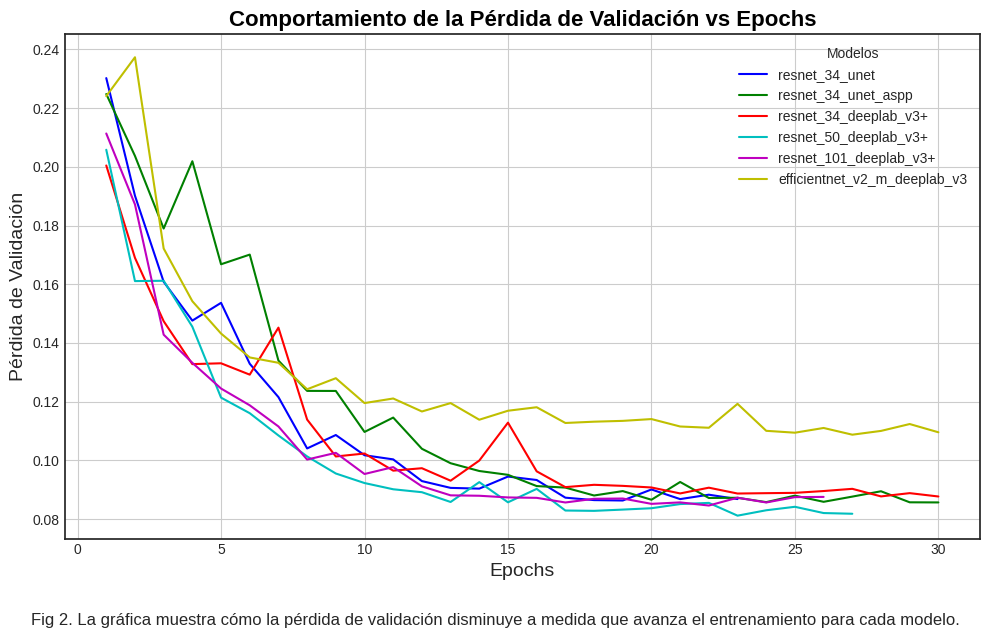

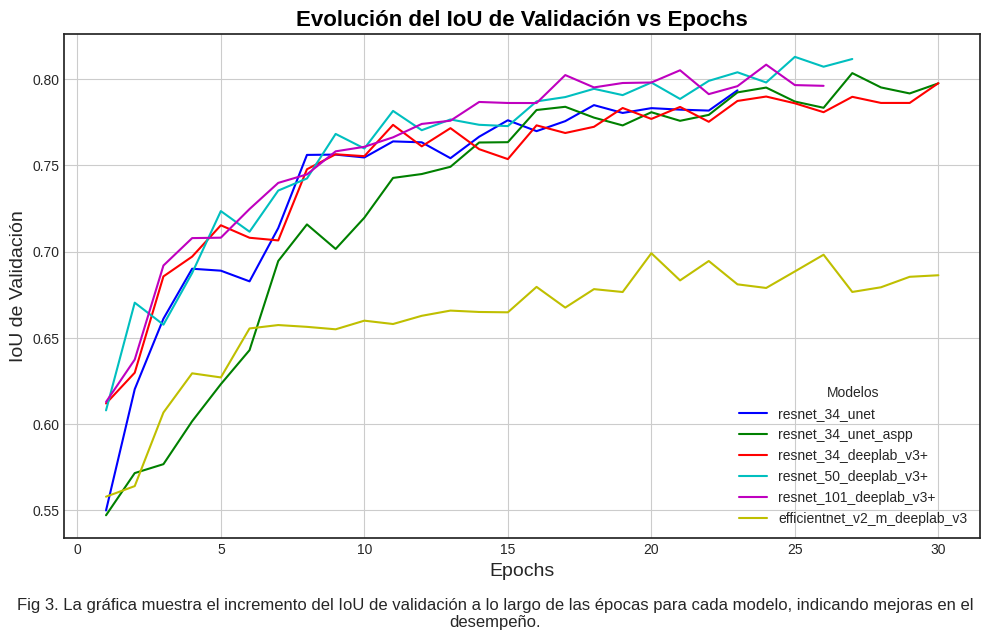

In [ ]:
import matplotlib.pyplot as plt

# Colores para cada modelo
colors = ['b', 'g', 'r', 'c', 'm', 'y']

# Configurar estilo
plt.style.use('seaborn-white')

# Definir fuentes y estilo compartido
title_font = {'size': '16', 'color': 'black', 'weight': 'bold'}
axis_font = {'size': '14'}
legend_font = {'fontsize': 12}
figtext_font = {'fontsize': 12}

# --- Gráfico de Pérdida de Validación vs Epochs ---

plt.figure(figsize=(10, 6))

for i, model in enumerate(model_names):
    if model in data:
        epochs = data[model]['epoch']
        valid_loss = data[model]['valid_loss']
        plt.plot(epochs, valid_loss, color=colors[i], label=model)

plt.xlabel('Epochs', fontdict=axis_font)
plt.ylabel('Pérdida de Validación', fontdict=axis_font)
plt.title('Comportamiento de la Pérdida de Validación vs Epochs', fontdict=title_font)
plt.legend(title='Modelos')
plt.grid(True)
plt.tight_layout()
plt.figtext(0.5, -0.05, 'Fig 2. La gráfica muestra cómo la pérdida de validación disminuye a medida que avanza el entrenamiento para cada modelo.', wrap=True, horizontalalignment='center', fontsize=12)

plt.savefig('valid_loss_vs_epochs_academic.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Gráfico de IoU de Validación vs Epochs ---

plt.figure(figsize=(10, 6))

for i, model in enumerate(model_names):
    if model in data:
        epochs = data[model]['epoch']
        iou = data[model]['valid_IOU']
        plt.plot(epochs, iou, color=colors[i], label=model)

plt.xlabel('Epochs', fontdict=axis_font)
plt.ylabel('IoU de Validación', fontdict=axis_font)
plt.title('Evolución del IoU de Validación vs Epochs', fontdict=title_font)
plt.legend(title='Modelos')
plt.grid(True)
plt.tight_layout()
plt.figtext(0.5, -0.05, 'Fig 3. La gráfica muestra el incremento del IoU de validación a lo largo de las épocas para cada modelo, indicando mejoras en el desempeño.', wrap=True, horizontalalignment='center', fontsize=12)

plt.savefig('valid_iou_vs_epochs_academic.png', dpi=300, bbox_inches='tight')
plt.show()


<ipython-input-107-3a14e1f7c1df>:5: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-white')


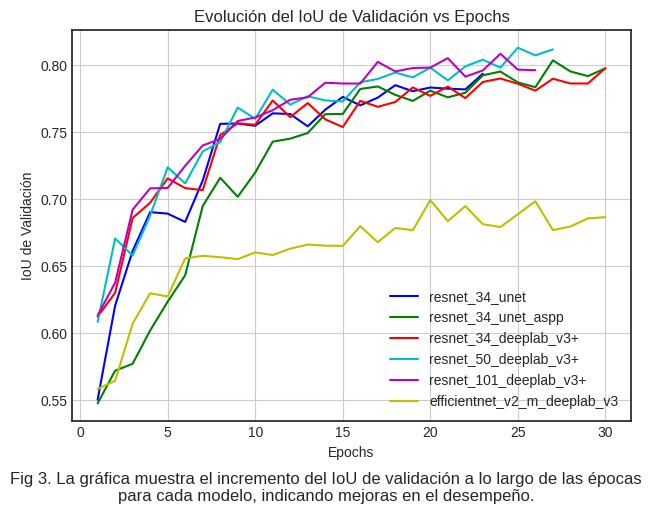

In [ ]:
# Configurar estilo
# Colores para cada modelo
colors = ['b', 'g', 'r', 'c', 'm', 'y']
# Configurar estilo
plt.style.use('seaborn-white')

for i, model in enumerate(model_names):
    if model in data:
        epochs = data[model]['epoch']
        iou = data[model]['valid_IOU']
        plt.plot(epochs, iou, color=colors[i], label=model)

plt.xlabel('Epochs')
plt.ylabel('IoU de Validación')
plt.title('Evolución del IoU de Validación vs Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.figtext(0.5, -0.05, 'Fig 3. La gráfica muestra el incremento del IoU de validación a lo largo de las épocas para cada modelo, indicando mejoras en el desempeño.', wrap=True, horizontalalignment='center', fontsize=12)

plt.savefig('valid_iou_vs_epochs_description.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

!cp "/content/drive/MyDrive/Results_multiple_oil_spill_final/models/efficientnet_v2_m_deeplab_v3/oil_spill_seg_efficientnet_v2_m_deeplab_v3_20.pt" "/content/efficientnet.csv"
!cp "/content/drive/MyDrive/Results_multiple_oil_spill_final/models/resnet_101_deeplab_v3+/oil_spill_seg_resnet_101_deeplab_v3+_24.pt" "/content/resnet101.csv"
!cp "/content/drive/MyDrive/Results_multiple_oil_spill_final/models/resnet_34_deeplab_v3+/oil_spill_seg_resnet_34_deeplab_v3+_30.pt" "/content/resnet34.csv"
!cp "/content/drive/MyDrive/Results_multiple_oil_spill_final/models/resnet_34_unet/oil_spill_seg_resnet_34_unet_23.pt" "/content/resnetunet_34.csv"
!cp "/content/drive/MyDrive/Results_multiple_oil_spill_final/models/resnet_34_unet_aspp/oil_spill_seg_resnet_34_unet_aspp_27.pt" "/content/resnetunet_34_aspp.csv"
!cp "/content/drive/MyDrive/Results_multiple_oil_spill_final/models/resnet_50_deeplab_v3+/oil_spill_seg_resnet_50_deeplab_v3+_25.pt" "/content/resnet50.csv"

In [ ]:
import os
import pandas as pd

def collect_best_models_metrics(models_dir='models'):
    model_metrics = []

    for model_name in os.listdir(models_dir):
        model_dir = os.path.join(models_dir, model_name)
        metrics_file = os.path.join(model_dir, 'train_metrics.csv')

        if os.path.isfile(metrics_file):
            # Read the train_metrics.csv file
            df = pd.read_csv(metrics_file)
            # Find the epoch with the best validation m-IOU%
            best_epoch = df['valid_IOU'].idxmax()
            best_miou = df.loc[best_epoch, 'valid_IOU']
            # Optionally, get other metrics like loss, accuracy
            # best_loss = df.loc[best_epoch, 'val_loss']
            model_metrics.append({
                'Model': model_name,
                'Best m-IOU%': best_miou,
                'Best Epoch': best_epoch + 1  # +1 if epochs are 1-indexed
            })
        else:
            print(f"No train_metrics.csv found for model: {model_name}")

    # Create a DataFrame with the collected metrics
    metrics_df = pd.DataFrame(model_metrics)
    return metrics_df

# Usage
metrics_df = collect_best_models_metrics()
print(metrics_df)


In [ ]:
best_model_row = metrics_df.loc[metrics_df['Best m-IOU%'].idxmax()]
best_model_name = best_model_row['Model']
best_model_miou = best_model_row['Best m-IOU%']
print(f"Best model is {best_model_name} with m-IOU% of {best_model_miou:.2f}")
metrics_df.to_csv('all_models_train_metrics.csv')

Best model is resnet_50_deeplab_v3+ with m-IOU% of 0.81


In [ ]:
import os
import shutil

# Define the destination directory in your Google Drive
drive_destination_dir = '/content/drive/MyDrive/Results_multiple_oil_spill_final_metricas'

# Create the directory if it doesn't exist
if not os.path.exists(drive_destination_dir):
    os.makedirs(drive_destination_dir)
    print(f"Created directory: {drive_destination_dir}")
else:
    print(f"Directory already exists: {drive_destination_dir}")

# Define the source file you want to copy
source_file = '/content/all_models_test_metrics.csv'  # This should be the file you've created

# Define the destination path where the file will be saved
destination_file = os.path.join(drive_destination_dir, 'all_models_test_metrics.csv')

# Copy the file to the destination directory
shutil.copy(source_file, destination_file)

print(f"File saved to: {destination_file}")


Directory already exists: /content/drive/MyDrive/Results_multiple_oil_spill_final_metricas
File saved to: /content/drive/MyDrive/Results_multiple_oil_spill_final_metricas/all_models_test_metrics.csv


In [ ]:
import os

# List of model names
model_names = [
    'resnet_34_unet',
    'resnet_34_unet_aspp',
    'resnet_34_deeplab_v3+',
    'resnet_50_deeplab_v3+',
    'resnet_101_deeplab_v3+',
    'efficientnet_v2_m_deeplab_v3',
]

# Create the main 'models' directory
os.makedirs('models', exist_ok=True)

# Create subdirectories for each model
for model_name in model_names:
    model_dir = os.path.join('models', model_name)
    os.makedirs(model_dir, exist_ok=True)
import shutil

# Path to your models in Google Drive
drive_models_dir = '/content/drive/MyDrive/Results_multiple_oil_spill_final/models/'

for model_name in model_names:
    # Define paths
    drive_model_dir = os.path.join(drive_models_dir, model_name)
    local_model_dir = os.path.join('models', model_name)

    # Copy 'train_metrics.csv'
    drive_metrics_file = os.path.join(drive_model_dir, 'train_metrics.csv')
    local_metrics_file = os.path.join(local_model_dir, 'train_metrics.csv')

    if os.path.exists(drive_metrics_file):
        shutil.copy(drive_metrics_file, local_metrics_file)
        print(f"Copied train_metrics.csv for {model_name}")
    else:
        print(f"train_metrics.csv not found for {model_name} in Google Drive")

    # Read 'train_metrics.csv' to find the best epoch
    import pandas as pd

    if os.path.exists(local_metrics_file):
        df_metrics = pd.read_csv(local_metrics_file)
        best_epoch_idx = df_metrics['valid_IOU'].idxmax()
        best_epoch = int(df_metrics.loc[best_epoch_idx, 'epoch'])

        # Construct the model filename
        model_filename = f'oil_spill_seg_{model_name}_{best_epoch}.pt'
        drive_model_file = os.path.join(drive_model_dir, model_filename)
        local_model_file = os.path.join(local_model_dir, model_filename)

        # Copy the .pt model file
        if os.path.exists(drive_model_file):
            shutil.copy(drive_model_file, local_model_file)
            print(f"Copied {model_filename} for {model_name}")
        else:
            print(f"Model file {model_filename} not found for {model_name} in Google Drive")
    else:
        print(f"Skipping model file copy for {model_name} due to missing metrics file")


Copied train_metrics.csv for resnet_34_unet
Copied oil_spill_seg_resnet_34_unet_23.pt for resnet_34_unet
Copied train_metrics.csv for resnet_34_unet_aspp
Copied oil_spill_seg_resnet_34_unet_aspp_27.pt for resnet_34_unet_aspp
Copied train_metrics.csv for resnet_34_deeplab_v3+
Copied oil_spill_seg_resnet_34_deeplab_v3+_30.pt for resnet_34_deeplab_v3+
Copied train_metrics.csv for resnet_50_deeplab_v3+
Copied oil_spill_seg_resnet_50_deeplab_v3+_25.pt for resnet_50_deeplab_v3+
Copied train_metrics.csv for resnet_101_deeplab_v3+
Copied oil_spill_seg_resnet_101_deeplab_v3+_24.pt for resnet_101_deeplab_v3+
Copied train_metrics.csv for efficientnet_v2_m_deeplab_v3
Copied oil_spill_seg_efficientnet_v2_m_deeplab_v3_20.pt for efficientnet_v2_m_deeplab_v3


In [ ]:
import os
import numpy as np
import torch
from skimage.io import imsave
import torch.nn.functional as F


def create_directory(dir_path):
    """Create a directory if it doesn't exist."""
    if not os.path.isdir(dir_path):
        os.makedirs(dir_path)
        print(f"Created directory: {dir_path}")

from skimage.io import imsave

def inference_loop(
    dataset_loader, model, dir_labels, dir_masks, num_classes, device, image_format=".png", selected_images=None
):
    model.eval()
    infer_acc = 0
    infer_class_IOU = []

    dict_label_to_color_mapping = {
        0: np.array([0, 0, 0]),
        1: np.array([0, 255, 255]),
        2: np.array([255, 0, 0]),
        3: np.array([153, 76, 0]),
        4: np.array([0, 153, 0]),
    }

    for idx, (images, labels) in enumerate(dataset_loader):
        images = images.to(device, dtype=torch.float)
        labels = labels.to(device, dtype=torch.long)

        with torch.no_grad():
            pred_logits = model(images)
            pred_probs = F.softmax(pred_logits, dim=1)
            pred_label = torch.argmax(pred_probs, dim=1)

        infer_acc += compute_mean_pixel_acc(labels, pred_label)
        infer_class_IOU_cur_sample = compute_class_IOU(labels, pred_label)
        infer_class_IOU.append(infer_class_IOU_cur_sample)

        # Convert predictions to numpy arrays
        pred_label_arr = pred_label.cpu().numpy().squeeze()
        pred_label_one_hot = np.eye(num_classes)[pred_label_arr]

        pred_mask_arr = np.zeros((pred_label_arr.shape[0], pred_label_arr.shape[1], 3))
        for sem_class in range(num_classes):
            curr_class_label = pred_label_one_hot[:, :, sem_class]
            curr_class_color_mapping = dict_label_to_color_mapping[sem_class]
            pred_mask_arr += curr_class_label[..., None] * curr_class_color_mapping

        pred_label_arr = pred_label_arr.astype(np.uint8)
        pred_mask_arr = pred_mask_arr.astype(np.uint8)

        # Use the original image filename for saving the predictions
        if selected_images is not None:
            image_filename = selected_images[idx]
            base_filename = os.path.splitext(image_filename)[0]
        else:
            base_filename = f"pred_{idx}"

        # Save predictions
        file_pred_label = os.path.join(dir_labels, f"{base_filename}_label{image_format}")
        file_pred_mask = os.path.join(dir_masks, f"{base_filename}_mask{image_format}")

        imsave(file_pred_label, pred_label_arr)
        imsave(file_pred_mask, pred_mask_arr)

    infer_acc /= len(dataset_loader)
    infer_class_IOU = np.array(infer_class_IOU)
    infer_per_class_IOU = np.nanmean(infer_class_IOU, axis=0)
    return infer_acc, infer_per_class_IOU
'''
def run_inference():
    """Run inference on a subset of 10 random images."""
    # Define the images and labels directories
    images_dir = dir_dataset  # This should point to the images directory
    labels_dir = dir_labels_dataset  # This should point to the labels directory

    # Create the dataset
    dataset = M4DSAROilSpillDataset(
        images_dir=images_dir,
        labels_dir=labels_dir,
        transform=image_transform,
    )

    # Get the list of image filenames
    list_inference_images = dataset.image_files

    # Select 10 random indices
    indices = np.random.choice(len(list_inference_images), 10, replace=False)

    # Create a subset of the dataset
    subset_dataset = torch.utils.data.Subset(dataset, indices)

    # Create a DataLoader for the subset
    subset_loader = torch.utils.data.DataLoader(subset_dataset, batch_size=1, shuffle=False)

    selected_images = [list_inference_images[i] for i in indices]

    print("Selected 10 random images for inference.")
    print(f"Number of test samples: {len(selected_images)}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if which_model == "resnet_34_unet":
        oil_spill_seg_model = ResNet34UNet(num_classes=num_classes, pretrained=bool(pretrained))
    elif which_model == "resnet_34_unet_aspp":
        oil_spill_seg_model = ResNet34UNetWithASPP(num_classes=num_classes, pretrained=bool(pretrained))
    else:
        print("Model not implemented.")
        return

    oil_spill_seg_model.to(device)
    oil_spill_seg_model.load_state_dict(torch.load(file_model_weights, map_location=device))

    create_directory(dir_labels)
    create_directory(dir_masks)

    infer_acc, infer_per_class_IOU = inference_loop(
        subset_loader,
        oil_spill_seg_model,
        dir_labels,
        dir_masks,
        num_classes,
        device,
        image_format=".png",
        selected_images=selected_images,
    )

    infer_acc *= 100
    infer_per_class_IOU *= 100
    infer_IOU = np.mean(infer_per_class_IOU)

    print("Inference test set metrics")
    print(f"Accuracy: {infer_acc:.3f}%")
    print(f"Mean IOU: {infer_IOU:.3f}%")
    print("Per class IOU:")
    print(infer_per_class_IOU)
'''

'\ndef run_inference():\n    """Run inference on a subset of 10 random images."""\n    # Define the images and labels directories\n    images_dir = dir_dataset  # This should point to the images directory\n    labels_dir = dir_labels_dataset  # This should point to the labels directory\n\n    # Create the dataset\n    dataset = M4DSAROilSpillDataset(\n        images_dir=images_dir,\n        labels_dir=labels_dir,\n        transform=image_transform,\n    )\n\n    # Get the list of image filenames\n    list_inference_images = dataset.image_files\n\n    # Select 10 random indices\n    indices = np.random.choice(len(list_inference_images), 10, replace=False)\n\n    # Create a subset of the dataset\n    subset_dataset = torch.utils.data.Subset(dataset, indices)\n\n    # Create a DataLoader for the subset\n    subset_loader = torch.utils.data.DataLoader(subset_dataset, batch_size=1, shuffle=False)\n\n    selected_images = [list_inference_images[i] for i in indices]\n\n    print("Selected 10 

In [ ]:
def main():
    # Set the device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Define the number of classes
    num_classes = 5  # Adjust based on your dataset

    # Define the directory where your models are saved
    models_dir = 'models'

    # Define the directory where predictions will be saved
    predictions_dir = 'predictions'

    # Define the Krestininis dataset directory
    krest_dir = '/content/drive/Othercomputers/MiPC/filtered_patches/'
    sos_dir = '/content/drive/Othercomputers/MiPC/OilDatasetSOS'
    # Get the test DataLoader
    test_loader, test_dataset = get_dataloader_for_inference(
        sos_dir=sos_dir,  # Not using SOS dataset in this case
        krest_dir=krest_dir,
        batch_size=1,
        num_workers=4,
    )

    # Get the list of image filenames
    test_image_files = []
    for dataset in test_dataset.datasets:
        test_image_files.extend(dataset.image_files)

    # Define the list of models explicitly
    model_names = [
        'resnet_34_unet',
        'resnet_34_unet_aspp',
        'resnet_34_deeplab_v3+',
        'resnet_50_deeplab_v3+',
        'resnet_101_deeplab_v3+',
        'efficientnet_v2_m_deeplab_v3',
        # Add other model names as needed
    ]

    # Run inference for each model
    for model_name in model_names:
        print(f"Running inference for model: {model_name}")
        model_dir = os.path.join(models_dir, model_name)

        # Read the train_metrics.csv to find the best epoch
        metrics_file = os.path.join(model_dir, 'train_metrics.csv')
        if not os.path.isfile(metrics_file):
            print(f"No train_metrics.csv found for model: {model_name}")
            continue

        # Read the metrics CSV
        df_metrics = pd.read_csv(metrics_file)

        # Find the best epoch based on the highest validation m-IOU%
        best_epoch_idx = df_metrics['valid_IOU'].idxmax()
        best_epoch = df_metrics.loc[best_epoch_idx, 'epoch']

        # Construct the filename of the best model
        # Assuming the model files are saved as 'oil_spill_seg_<model_name>_<epoch>.pt'
        # e.g., 'oil_spill_seg_resnet_34_unet_5.pt'
        model_filename = f'oil_spill_seg_{model_name}_{int(best_epoch)}.pt'
        model_weights_path = os.path.join(model_dir, model_filename)
        if not os.path.isfile(model_weights_path):
            print(f"No model weights found for {model_name} at {model_weights_path}")
            continue

        # Initialize the model
        if model_name == "resnet_34_deeplab_v3+":
            model = ResNet34DeepLabV3Plus(num_classes=num_classes, pretrained=False)

        else:
            print(f"Model {model_name} not recognized.")
            continue
        '''
        if model_name == "resnet_34_unet":
            model = ResNet34UNet(num_classes=num_classes, pretrained=False)
        elif model_name == "resnet_34_unet_aspp":
            model = ResNet34UNetWithASPP(num_classes=num_classes, pretrained=False)
        if model_name == "resnet_34_deeplab_v3+":
            model = ResNet34DeepLabV3Plus(num_classes=num_classes, pretrained=False)
        elif model_name == "resnet_50_deeplab_v3+":
            model = ResNet50DeepLabV3Plus(num_classes=num_classes, pretrained=False)
        elif model_name == "resnet_101_deeplab_v3+":
            model = ResNet101DeepLabV3Plus(num_classes=num_classes, pretrained=False)
        elif model_name == "efficientnet_v2_m_deeplab_v3":
            model = EfficientNetMDeepLabV3(num_classes=num_classes, pretrained=False)
        else:
            print(f"Model {model_name} not recognized.")
            continue
        '''
        # Load the model weights
        model.load_state_dict(torch.load(model_weights_path, map_location=device))
        model.to(device)

        # Define directories to save predictions
        model_predictions_dir = os.path.join(predictions_dir, model_name)
        dir_labels = os.path.join(model_predictions_dir, 'labels')
        dir_masks = os.path.join(model_predictions_dir, 'masks')
        create_directory(dir_labels)
        create_directory(dir_masks)

        # Run inference
        infer_acc, infer_per_class_IOU = inference_loop(
            dataset_loader=test_loader,
            model=model,
            dir_labels=dir_labels,
            dir_masks=dir_masks,
            num_classes=num_classes,
            device=device,
            image_format=".png",
            selected_images=test_image_files,
        )

        infer_acc *= 100
        infer_per_class_IOU *= 100
        infer_IOU = np.nanmean(infer_per_class_IOU)

        print(f"Inference completed for model: {model_name}")
        print(f"Accuracy: {infer_acc:.2f}%")
        print(f"Mean IOU: {infer_IOU:.2f}%")
        print(f"Per class IOU: {infer_per_class_IOU}")

        # Save test metrics
        test_metrics = {
            'Model': model_name,
            'Test Accuracy (%)': infer_acc,
            'Test Mean IOU (%)': infer_IOU,
        }
        for i, class_iou in enumerate(infer_per_class_IOU):
            test_metrics[f'Class {i} IOU (%)'] = class_iou

        # Save test metrics to a CSV file
        test_metrics_file = os.path.join(model_predictions_dir, 'test_metrics.csv')
        test_metrics_df = pd.DataFrame([test_metrics])
        test_metrics_df.to_csv(test_metrics_file, index=False)

        print(f"Test metrics saved to {test_metrics_file}")

    print("Inference process completed for all models.")

if __name__ == '__main__':
    main()


Running inference for model: resnet_34_unet
Model resnet_34_unet not recognized.
Running inference for model: resnet_34_unet_aspp
Model resnet_34_unet_aspp not recognized.
Running inference for model: resnet_34_deeplab_v3+
Created directory: predictions/resnet_34_deeplab_v3+/labels
Created directory: predictions/resnet_34_deeplab_v3+/masks


Se truncaron las últimas líneas 5000 del resultado de transmisión.
<ipython-input-41-45bce5536aef>:68: UserWarning: predictions/resnet_34_deeplab_v3+/labels/20766_sat_label.png is a low contrast image
  imsave(file_pred_label, pred_label_arr)
<ipython-input-41-45bce5536aef>:68: UserWarning: predictions/resnet_34_deeplab_v3+/labels/20767_sat_label.png is a low contrast image
  imsave(file_pred_label, pred_label_arr)
<ipython-input-41-45bce5536aef>:68: UserWarning: predictions/resnet_34_deeplab_v3+/labels/20768_sat_label.png is a low contrast image
  imsave(file_pred_label, pred_label_arr)
<ipython-input-41-45bce5536aef>:68: UserWarning: predictions/resnet_34_deeplab_v3+/labels/20769_sat_label.png is a low contrast image
  imsave(file_pred_label, pred_label_arr)
<ipython-input-41-45bce5536aef>:68: UserWarning: predictions/resnet_34_deeplab_v3+/labels/20770_sat_label.png is a low contrast image
  imsave(file_pred_label, pred_label_arr)
<ipython-input-41-45bce5536aef>:68: UserWarning: pred

Inference completed for model: resnet_34_deeplab_v3+
Accuracy: 91.45%
Mean IOU: 61.88%
Per class IOU: [86.89840854 55.75702508 43.11871222 35.26010323 88.36551205]
Test metrics saved to predictions/resnet_34_deeplab_v3+/test_metrics.csv
Running inference for model: resnet_50_deeplab_v3+
Model resnet_50_deeplab_v3+ not recognized.
Running inference for model: resnet_101_deeplab_v3+
Model resnet_101_deeplab_v3+ not recognized.
Running inference for model: efficientnet_v2_m_deeplab_v3
Model efficientnet_v2_m_deeplab_v3 not recognized.
Inference process completed for all models.


<ipython-input-41-45bce5536aef>:68: UserWarning: predictions/resnet_34_deeplab_v3+/labels/img_0110_3_label.png is a low contrast image
  imsave(file_pred_label, pred_label_arr)
<ipython-input-41-45bce5536aef>:68: UserWarning: predictions/resnet_34_deeplab_v3+/labels/img_0110_4_label.png is a low contrast image
  imsave(file_pred_label, pred_label_arr)
<ipython-input-41-45bce5536aef>:68: UserWarning: predictions/resnet_34_deeplab_v3+/labels/img_0110_5_label.png is a low contrast image
  imsave(file_pred_label, pred_label_arr)
<ipython-input-41-45bce5536aef>:68: UserWarning: predictions/resnet_34_deeplab_v3+/labels/img_0110_6_label.png is a low contrast image
  imsave(file_pred_label, pred_label_arr)
<ipython-input-41-45bce5536aef>:68: UserWarning: predictions/resnet_34_deeplab_v3+/labels/img_0110_7_label.png is a low contrast image
  imsave(file_pred_label, pred_label_arr)
<ipython-input-41-45bce5536aef>:68: UserWarning: predictions/resnet_34_deeplab_v3+/labels/img_0110_8_label.png is a

In [ ]:
def collect_test_metrics(predictions_dir='predictions'):
    test_metrics_list = []

    for model_name in os.listdir(predictions_dir):
        model_pred_dir = os.path.join(predictions_dir, model_name)
        test_metrics_file = os.path.join(model_pred_dir, 'test_metrics.csv')

        if os.path.isfile(test_metrics_file):
            test_metrics_df = pd.read_csv(test_metrics_file)
            test_metrics_list.append(test_metrics_df)
        else:
            print(f"No test_metrics.csv found for model: {model_name}")

    # Concatenate all test metrics into a single DataFrame
    all_test_metrics_df = pd.concat(test_metrics_list, ignore_index=True)
    return all_test_metrics_df

# Usage
all_test_metrics_df = collect_test_metrics()
print(all_test_metrics_df)


                          Model  Test Accuracy (%)  Test Mean IOU (%)  \
0        resnet_101_deeplab_v3+          91.650537          61.369267   
1  efficientnet_v2_m_deeplab_v3          91.639221          50.655056   
2                resnet_34_unet          91.220915          62.109116   
3         resnet_50_deeplab_v3+          91.657163          60.820463   
4           resnet_34_unet_aspp          91.566175          61.556236   
5         resnet_34_deeplab_v3+          91.450696          61.879952   

   Class 0 IOU (%)  Class 1 IOU (%)  Class 2 IOU (%)  Class 3 IOU (%)  \
0        87.020935        56.608427        43.889579        32.630767   
1        86.271805        45.880386        40.890941         4.361723   
2        86.627771        56.629836        42.944057        36.704892   
3        86.961632        55.310501        42.195420        32.217484   
4        86.903625        56.555495        43.594215        33.535812   
5        86.898409        55.757025        43.1187

In [ ]:
# Save the consolidated test metrics to a CSV file
all_test_metrics_df.to_csv('all_models_test_metrics.csv', index=False)


In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os

class UnlabeledTIFDataset(Dataset):
    def __init__(self, images_dir, transform=None):
        self.images_dir = images_dir
        self.transform = transform

        # Get list of .tif image files
        self.image_files = sorted([
            f for f in os.listdir(self.images_dir)
            if f.endswith('.tif')
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # Get image file path
        image_file = self.image_files[idx]
        image_path = os.path.join(self.images_dir, image_file)

        # Load image
        image = Image.open(image_path).convert('RGB')

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        return image, image_file  # Return image and its filename


Created directory: /content/drive/MyDrive/TideHunter_RiseMaster_results


In [ ]:
image_transform = transforms.Compose([
    transforms.Resize((256, 256)),  # Adjust based on your model's expected input size
    transforms.ToTensor(),
    # Add any other preprocessing steps used during training
    # For example, normalization:
    # transforms.Normalize(mean=[0.485, 0.456, 0.406],
    #                      std=[0.229, 0.224, 0.225]),
])


In [ ]:
import torch
from torchvision import transforms

# Assuming you have the model class defined somewhere
# from your_model_module import ResNet34UNet

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model
num_classes = 5  # Adjust based on your model's number of classes
model = ResNet34UNet(num_classes=num_classes, pretrained=False)
model.to(device)

# Load the trained weights
model_weights_path = '/content/models/resnet_34_unet/oil_spill_seg_resnet_34_unet_<best_epoch>.pt'  # Replace <best_epoch> with the actual epoch number
model.load_state_dict(torch.load(model_weights_path, map_location=device))
model.eval()  # Set model to evaluation mode


In [ ]:
# Directory containing your .tif images
images_dir = '/content/drive/MyDrive/oefa_img_v4_256'

# Create the dataset and dataloader
dataset = UnlabeledTIFDataset(images_dir=images_dir, transform=image_transform)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)


In [ ]:
# Directory containing your .tif images
images_dir = '/content/drive/MyDrive/Results_multiple_oil_spill_final_metricas/all_models_train_metrics.csv'

# Load the CSV file into a DataFrame
train = pd.read_csv(images_dir)

# Display the DataFrame
train  # Check the first few rows

,Unnamed: 0,Model,Best m-IOU%,Best Epoch
0,0,efficientnet_v2_m_deeplab_v3,0.69903,20
1,1,resnet_101_deeplab_v3+,0.80830,24
2,2,resnet_34_deeplab_v3+,0.79757,30
3,3,resnet_34_unet,0.79341,23
4,4,resnet_34_unet_aspp,0.80340,27
5,5,resnet_50_deeplab_v3+,0.81282,25


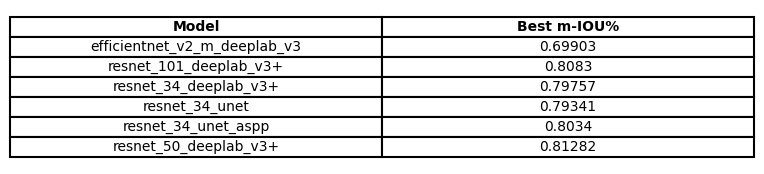

In [ ]:
df_selected = train.iloc[:, 1:3]
df = df_selected

# Create a table figure
fig, ax = plt.subplots(figsize=(8, 2))  # Adjust the size accordingly

# Hide axes
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.set_frame_on(False)

# Create the table without lines between registers
table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')

# Style the table: remove cell lines for the body, but add borders and middle line
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

# Set header to bold and keep its lines
for (i, j), cell in table.get_celld().items():
    if i == 0:  # header row
        cell.set_text_props(weight='bold')
        cell.set_edgecolor('black')
        cell.set_linewidth(1.5)  # thicker lines for the header
    else:
        if j == 0 or j == 1:  # borders and middle vertical line
            cell.set_edgecolor('black')  # keep the borders and middle vertical line
            cell.set_linewidth(1.5)
        else:
            cell.set_edgecolor('white')  # remove internal row lines

# Save the figure as an image
plt.savefig('formatted_table_border_lines.png', bbox_inches='tight', dpi=300)

# Show the table
plt.show()

In [ ]:
# Directory containing your .tif images
images_dir = '/content/drive/MyDrive/Results_multiple_oil_spill_final_metricas/all_models_test_metrics.csv'

# Load the CSV file into a DataFrame
test = pd.read_csv(images_dir)

# Display the DataFrame
test  # Check the first few rows

,Model,Test Accuracy (%),Test Mean IOU (%),Class 0 IOU (%),Class 1 IOU (%),Class 2 IOU (%),Class 3 IOU (%),Class 4 IOU (%)
0,resnet_101_deeplab_v3+,91.650537,61.369267,87.020935,56.608427,43.889579,32.630767,86.696626
1,efficientnet_v2_m_deeplab_v3,91.639221,50.655056,86.271805,45.880386,40.890941,4.361723,75.870428
2,resnet_34_unet,91.220915,62.109116,86.627771,56.629836,42.944057,36.704892,87.639023
3,resnet_50_deeplab_v3+,91.657163,60.820463,86.961632,55.310501,42.195420,32.217484,87.417276
4,resnet_34_unet_aspp,91.566175,61.556236,86.903625,56.555495,43.594215,33.535812,87.192035
5,resnet_34_deeplab_v3+,91.450696,61.879952,86.898409,55.757025,43.118712,35.260103,88.365512


In [ ]:
test_cleaned = test.drop(test.columns[1], axis=1)

In [ ]:
test_cleaned

,Model,Test Mean IOU (%),Class 0 IOU (%),Class 1 IOU (%),Class 2 IOU (%),Class 3 IOU (%),Class 4 IOU (%)
0,resnet_101_deeplab_v3+,61.369267,87.020935,56.608427,43.889579,32.630767,86.696626
1,efficientnet_v2_m_deeplab_v3,50.655056,86.271805,45.880386,40.890941,4.361723,75.870428
2,resnet_34_unet,62.109116,86.627771,56.629836,42.944057,36.704892,87.639023
3,resnet_50_deeplab_v3+,60.820463,86.961632,55.310501,42.195420,32.217484,87.417276
4,resnet_34_unet_aspp,61.556236,86.903625,56.555495,43.594215,33.535812,87.192035
5,resnet_34_deeplab_v3+,61.879952,86.898409,55.757025,43.118712,35.260103,88.365512


In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np

# 1. Load the Trained Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 5  # Adjust based on your model

# Ensure ResNet34UNet is defined or imported
# from your_model_module import ResNet34UNet

model = ResNet34UNet(num_classes=num_classes, pretrained=False)
model.to(device)
model_weights_path = '/content/models/resnet_34_unet/oil_spill_seg_resnet_34_unet_23.pt' # Replace <best_epoch> with actual epoch
model.load_state_dict(torch.load(model_weights_path, map_location=device))
model.eval()

# 2. Prepare the Data Loader
class UnlabeledPNGDataset(Dataset):
    def __init__(self, images_dir):
        self.images_dir = images_dir
        self.image_files = sorted([
            f for f in os.listdir(self.images_dir)
            if f.endswith('.png')
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_file = self.image_files[idx]
        image_path = os.path.join(self.images_dir, image_file)
        image = Image.open(image_path).convert('RGB')
        image = self.pil_to_tensor(image)
        return image, image_file

    @staticmethod
    def pil_to_tensor(pic):
        # Convert PIL Image to tensor
        import torchvision.transforms.functional as TF
        return TF.to_tensor(pic)

# 3. Create Data Loader
images_dir = '/content/drive/Othercomputers/MiPC/Code_OilSpill/Apis/last_dance/osinergmin_trial1_256_repsol_v2'
dataset = UnlabeledPNGDataset(images_dir=images_dir)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

# 4. Run Inference and Save Predicted Labels with Colormap
output_dir = '/content/resnetunet_pred_repsol_v2'
os.makedirs(output_dir, exist_ok=True)

# Define a colormap
colormap = [
    (0, 0, 0),       # Class 0
    (0, 255, 255),   # Class 1
    (255, 0, 0),     # Class 2
    (153, 76, 0),    # Class 3
    (0, 153, 0),     # Class 4
    # Add more colors if needed
]

def apply_colormap(label, colormap):
    color_label = np.zeros((label.shape[0], label.shape[1], 3), dtype=np.uint8)
    for idx, color in enumerate(colormap):
        mask = label == idx
        color_label[mask] = color
    return color_label

model.eval()
with torch.no_grad():
    for images, image_files in dataloader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        for i in range(images.size(0)):
            pred_label = preds[i].astype(np.uint8)
            image_file = image_files[i]
            # Apply colormap
            pred_colored = apply_colormap(pred_label, colormap)
            # Save the colored label
            output_filename = os.path.splitext(image_file)[0] + '_label.png'
            output_path = os.path.join(output_dir, output_filename)
            pred_label_img = Image.fromarray(pred_colored)
            pred_label_img.save(output_path)
            print(f"Saved colored label for {image_file} to {output_path}")


<ipython-input-91-c179bc2c5409>:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_weights_path, map_location=device))


Saved colored label for 10_2022-01-25_image.png to /content/resnetunet_pred_repsol_v2/10_2022-01-25_image_label.png
Saved colored label for 11_2022-01-25_image.png to /content/resnetunet_pred_repsol_v2/11_2022-01-25_image_label.png
Saved colored label for 12_2022-01-25_image.png to /content/resnetunet_pred_repsol_v2/12_2022-01-25_image_label.png
Saved colored label for 13_2022-01-25_image.png to /content/resnetunet_pred_repsol_v2/13_2022-01-25_image_label.png
Saved colored label for 14_2022-01-25_image.png to /content/resnetunet_pred_repsol_v2/14_2022-01-25_image_label.png
Saved colored label for 15_2022-01-25_image.png to /content/resnetunet_pred_repsol_v2/15_2022-01-25_image_label.png
Saved colored label for 16_2022-01-25_image.png to /content/resnetunet_pred_repsol_v2/16_2022-01-25_image_label.png
Saved colored label for 17_2022-01-25_image.png to /content/resnetunet_pred_repsol_v2/17_2022-01-25_image_label.png
Saved colored label for 18_2022-01-25_image.png to /content/resnetunet_p

In [ ]:
from torch.utils.data import Dataset, DataLoader
import tifffile
import numpy as np
import os

In [ ]:
/content/drive/Othercomputers/MiPC/Code_OilSpill/Apis/last_dance/osinergmin_trial1_256

In [ ]:
import os
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
from skimage.io import imsave
import tifffile  # Added import

# 1. Load the Trained Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 5  # Adjust based on your model

# Ensure ResNet34UNet is defined or imported
# from your_model_module import ResNet34UNet

model = ResNet34UNet(num_classes=num_classes, pretrained=False)
model.to(device)
model_weights_path = '/content/models/resnet_34_unet/oil_spill_seg_resnet_34_unet_23.pt'
model.load_state_dict(torch.load(model_weights_path, map_location=device))
model.eval()

from torch.utils.data import Dataset
import tifffile
from PIL import Image
import numpy as np
import os

from torch.utils.data import Dataset
import rasterio
from PIL import Image
import numpy as np

class UnlabeledTIFDataset(Dataset):
    def __init__(self, images_dir, transform=None):
        self.images_dir = images_dir
        self.transform = transform
        self.image_files = sorted([
            f for f in os.listdir(self.images_dir)
            if f.endswith('.tif')
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_file = self.image_files[idx]
        image_path = os.path.join(self.images_dir, image_file)

        with rasterio.open(image_path) as src:
            image = src.read()  # (channels, height, width)

        # Handle NaN or infinite values
        image = np.nan_to_num(image, nan=0.0, posinf=0.0, neginf=0.0)

        # Normalize or scale image data if necessary
        if image.dtype != np.uint8:
            min_val = np.min(image)
            max_val = np.max(image)
            if max_val - min_val > 0:
                image = (image - min_val) / (max_val - min_val)  # Normalize to 0-1
            else:
                image = np.zeros_like(image)
            image = (image * 255).astype(np.uint8)

        # Handle multi-band images
        if image.shape[0] == 1:
            # Single-channel image, replicate to 3 channels
            image = np.repeat(image, 3, axis=0)
        elif image.shape[0] == 2:
            # Two-channel image, create a third channel
            channel3 = ((image[0] + image[1]) / 2).astype(image.dtype)
            image = np.concatenate([image, channel3[np.newaxis, :, :]], axis=0)
        elif image.shape[0] >= 3:
            # Use the first three channels
            image = image[:3, :, :]
        else:
            # Other cases, replicate to 3 channels
            image = np.tile(image, (3, 1, 1))

        # Debugging: Print shape after channel adjustments
        print(f"Image shape after channel adjustments: {image.shape}")

        # Transpose to (height, width, channels)
        image = np.transpose(image, (1, 2, 0))

        # Debugging: Print shape after transpose
        print(f"Image shape after transpose: {image.shape}")

        # Convert to PIL Image
        image = Image.fromarray(image)

        # Ensure image is in RGB mode
        if image.mode != 'RGB':
            image = image.convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, image_file




image_transform = transforms.Compose([
    transforms.Resize((256, 256)),  # Corrected size
    transforms.ToTensor(),
    # Add normalization if used during training
])

# 3. Create Data Loader
images_dir = '/content/drive/MyDrive/oefa_img_v4_256_real (1)'
dataset = UnlabeledTIFDataset(images_dir=images_dir, transform=image_transform)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

# 4. Run Inference and Save Predicted Masks
output_dir = '/content/predicted_masks_repsol'
os.makedirs(output_dir, exist_ok=True)

colormap = [
    (0, 0, 0),
    (0, 255, 255),
    (255, 0, 0),
    (153, 76, 0),
    (0, 153, 0),   # Class 4
    # Add more colors if needed
]

def decode_segmap(image, colormap):
    r = np.zeros_like(image).astype(np.uint8)
    g = np.zeros_like(image).astype(np.uint8)
    b = np.zeros_like(image).astype(np.uint8)
    for l in range(0, len(colormap)):
        idx = image == l
        r[idx] = colormap[l][0]
        g[idx] = colormap[l][1]
        b[idx] = colormap[l][2]
    rgb = np.stack([r, g, b], axis=2)
    return rgb

model.eval()
with torch.no_grad():
    for images, image_files in dataloader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        for i in range(images.size(0)):
            pred = preds[i]
            image_file = image_files[i]
            pred_colored = decode_segmap(pred, colormap)
            output_filename = os.path.splitext(image_file)[0] + '_mask.png'
            output_path = os.path.join(output_dir, output_filename)
            imsave(output_path, pred_colored)
            print(f"Saved mask for {image_file} to {output_path}")


<ipython-input-83-6d4732531dff>:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_weights_path, map_location=device))


Image shape after channel adjustments: (3, 256, 257)
Image shape after transpose: (256, 257, 3)
Saved mask for 10_2015-05-27_S1_GRD.tif to /content/predicted_masks/10_2015-05-27_S1_GRD_mask.png
Image shape after channel adjustments: (3, 256, 256)
Image shape after transpose: (256, 256, 3)
Saved mask for 13_2017-07-18_S1_GRD.tif to /content/predicted_masks/13_2017-07-18_S1_GRD_mask.png
Image shape after channel adjustments: (3, 256, 256)
Image shape after transpose: (256, 256, 3)
Saved mask for 13_2017-07-21_S1_GRD.tif to /content/predicted_masks/13_2017-07-21_S1_GRD_mask.png
Image shape after channel adjustments: (3, 256, 256)
Image shape after transpose: (256, 256, 3)
Saved mask for 14_2018-04-05_S1_GRD.tif to /content/predicted_masks/14_2018-04-05_S1_GRD_mask.png
Image shape after channel adjustments: (3, 256, 256)
Image shape after transpose: (256, 256, 3)
Saved mask for 14_2018-04-06_S1_GRD.tif to /content/predicted_masks/14_2018-04-06_S1_GRD_mask.png
Image shape after channel adju

In [ ]:
image_path = '/content/drive/MyDrive/oefa_img_v4_256_real (1)/23_2022-01-25_S1_GRD.tif'
with rasterio.open(image_path) as src:
    image = src.read()  # Reads in (channels, height, width)
print(f"Image shape: {image.shape}, dtype: {image.dtype}")

Image shape: (2, 256, 256), dtype: float32


In [ ]:
import shutil
import os

# Define source and destination paths
source = '/content/resnetunet_pred_oefa'
destination = '/content/drive/My Drive/predictions_backup'

# Ensure the destination directory exists
os.makedirs(destination, exist_ok=True)

# Copy the entire folder recursively
shutil.copytree(source, destination, dirs_exist_ok=True)

print(f"Folder copied to {destination}")


Folder copied to /content/drive/My Drive/predictions_backup
